# NBA Home Team Win Prediction
## BA576 - Machine Learning for Business Analytics

**Prediction Problem:** Given pre-game information about two NBA teams (season rankings, historical performance, conference), can we predict whether the home team will win?

**Target Variable:** `HOME_TEAM_WINS` (binary: 1 = home win, 0 = away win)

**Why this matters:** Sports betting, team strategy, and broadcast planning all benefit from accurate game outcome predictions. A model that beats the naive baseline (home teams win ~59% of games) would have real-world value.

---
## 1. Setup and Data Import

In [32]:
import os, warnings
os.environ['OMP_NUM_THREADS'] = '1'

# Core Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, brier_score_loss, log_loss
)
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from itertools import product

# Global Constants
RANDOM_STATE = 42
ROLLING_WINDOW_5 = 5
ROLLING_WINDOW_10 = 10
TEST_SEASONS = [2021, 2022]
CV_SPLITS = 5

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
os.makedirs('plots', exist_ok=True)

In [2]:
import os
DATA_DIR = 'data' if os.path.exists('data/games.csv') else '../data-ba576project'

games = pd.read_csv(f'{DATA_DIR}/games.csv')
details = pd.read_csv(f'{DATA_DIR}/games_details.csv',
                      usecols=['GAME_ID', 'TEAM_ID', 'COMMENT'])
players = pd.read_csv(f'{DATA_DIR}/players.csv')
ranking = pd.read_csv(f'{DATA_DIR}/ranking.csv')
teams = pd.read_csv(f'{DATA_DIR}/teams.csv')

print('Dataset shapes:')
for name, df in [('games', games), ('details', details), ('players', players),
                 ('ranking', ranking), ('teams', teams)]:
    print(f'  {name:>15s}: {df.shape[0]:>7,} rows x {df.shape[1]:>2} cols')

Dataset shapes:
            games:  26,651 rows x 21 cols
          details: 668,628 rows x  3 cols
          players:   7,228 rows x  4 cols
          ranking: 210,342 rows x 13 cols
            teams:      30 rows x 14 cols


---
## 2. Data Exploration and Cleaning

### 2.1 games.csv

Inspect the file and check for missing values

In [3]:
print('=== games.csv ===')
display(games.head())

missing = games.isnull().sum()
print(f'\nMissing values (non-zero only):')
print(missing[missing > 0])
print(f'\nTotal rows: {len(games):,}')
print(f'Rows with any missing: {games.isnull().any(axis=1).sum()}')

=== games.csv ===


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0



Missing values (non-zero only):
PTS_home        99
FG_PCT_home     99
FT_PCT_home     99
FG3_PCT_home    99
AST_home        99
REB_home        99
PTS_away        99
FG_PCT_away     99
FT_PCT_away     99
FG3_PCT_away    99
AST_away        99
REB_away        99
dtype: int64

Total rows: 26,651
Rows with any missing: 99


The 99 missing rows seem to be systematic => see if this is in a particular season

In [4]:
missing_rows = games[games.isnull().any(axis=1)]

missing_by_season = (
    missing_rows['SEASON']
    .value_counts()
    .sort_index()
)

print("\nMissing game rows by season:")
print(missing_by_season)

print(missing_rows)


Missing game rows by season:
SEASON
2003    99
Name: count, dtype: int64
      GAME_DATE_EST   GAME_ID GAME_STATUS_TEXT  HOME_TEAM_ID  VISITOR_TEAM_ID  \
19175    2003-10-24  10300116            Final    1610612753       1610612762   
19176    2003-10-24  10300108            Final    1610612737       1610612764   
19177    2003-10-24  10300109            Final    1610612738       1610612751   
19178    2003-10-24  10300113            Final    1610612759       1610612745   
19179    2003-10-24  10300112            Final    1610612749       1610612765   
...             ...       ...              ...           ...              ...   
19269    2003-10-09  10300019            Final    1610612743       1610612756   
19270    2003-10-09  10300022            Final    1610612757       1610612758   
19271    2003-10-08  10300013            Final    1610612759       1610612763   
19278    2003-10-08  10300015            Final    1610612747       1610612744   
19279    2003-10-07  10300006      

Since the missingness concentrated in October 2023 (problem w/ data availability), and since 99 rows only account for only 0.37% of the dataset, we could safely drop all missing values

In [5]:
games_clean = games[~games.isnull().any(axis=1)]

print(f'Games after cleaning: {len(games_clean):,}')
print(f'Home win rate: {games_clean["HOME_TEAM_WINS"].mean():.3f}')

Games after cleaning: 26,552
Home win rate: 0.589


Check for duplicate GAME_IDs

In [6]:
print('Seasons in games:', sorted(games['SEASON'].unique()))
print(f'Date range: {games["GAME_DATE_EST"].min()} to {games["GAME_DATE_EST"].max()}')
print(f'Number of unique teams: {games["HOME_TEAM_ID"].nunique()}')

dupes = games['GAME_ID'].duplicated().sum()
print(f'Duplicate GAME_IDs: {dupes} ✓')

Seasons in games: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Date range: 2003-10-05 to 2022-12-22
Number of unique teams: 30
Duplicate GAME_IDs: 29 ✓


Investigate the 29 duplicate GAME_IDs

In [7]:
dupe_ids = games[games['GAME_ID'].duplicated(keep=False)]['GAME_ID'].unique()
print(f'Number of duplicated GAME_IDs: {len(dupe_ids)}')

dupe_rows = games[games['GAME_ID'].isin(dupe_ids)].sort_values('GAME_ID')
display(dupe_rows[['GAME_ID', 'GAME_DATE_EST', 'SEASON', 'HOME_TEAM_ID',
                    'VISITOR_TEAM_ID', 'PTS_home', 'PTS_away', 'HOME_TEAM_WINS']])

Number of duplicated GAME_IDs: 29


,GAME_ID,GAME_DATE_EST,SEASON,HOME_TEAM_ID,VISITOR_TEAM_ID,PTS_home,PTS_away,HOME_TEAM_WINS
3125,22000006,2020-12-25,2020,1610612749,1610612744,138.0,99.0,1
2535,22000006,2020-12-25,2020,1610612749,1610612744,138.0,99.0,1
3126,22000007,2020-12-25,2020,1610612738,1610612751,95.0,123.0,0
2536,22000007,2020-12-25,2020,1610612738,1610612751,95.0,123.0,0
3127,22000011,2020-12-23,2020,1610612754,1610612752,121.0,107.0,1
2540,22000011,2020-12-23,2020,1610612754,1610612752,121.0,107.0,1
3128,22000013,2020-12-23,2020,1610612755,1610612764,113.0,107.0,1
2542,22000013,2020-12-23,2020,1610612755,1610612764,113.0,107.0,1
3129,22000015,2020-12-23,2020,1610612741,1610612737,104.0,124.0,0
2545,22000015,2020-12-23,2020,1610612741,1610612737,104.0,124.0,0


Since these are exact duplicates, we can safely drop those rows

In [8]:
print(f'Rows before dedup: {len(games):,}')

games_clean = games_clean.drop_duplicates(subset='GAME_ID', keep='first')

print(f'Rows after dedup:  {len(games_clean):,}')

Rows before dedup: 26,651
Rows after dedup:  26,523


### 2.2 ranking.csv

Inspect the file and check for missing values

In [9]:
print('=== ranking.csv ===')
display(ranking.head())

missing_rank = ranking.isnull().sum()
print(f'\nMissing values (non-zero only):')
print(missing_rank[missing_rank > 0])

=== ranking.csv ===


,TEAM_ID,LEAGUE_ID,SEASON_ID,STANDINGSDATE,CONFERENCE,TEAM,G,W,L,W_PCT,HOME_RECORD,ROAD_RECORD,RETURNTOPLAY
0,1610612743,0,22022,2022-12-22,West,Denver,30,19,11,0.633,10-3,9-8,NaN
1,1610612763,0,22022,2022-12-22,West,Memphis,30,19,11,0.633,13-2,6-9,NaN
2,1610612740,0,22022,2022-12-22,West,New Orleans,31,19,12,0.613,13-4,6-8,NaN
3,1610612756,0,22022,2022-12-22,West,Phoenix,32,19,13,0.594,14-4,5-9,NaN
4,1610612746,0,22022,2022-12-22,West,LA Clippers,33,19,14,0.576,11-7,8-7,NaN



Missing values (non-zero only):
RETURNTOPLAY    206352
dtype: int64


Drop RETURNTOPLAY (a COVID-era flag) — 98% null and not useful

In [10]:
ranking = ranking.drop(columns=['RETURNTOPLAY'])

In [11]:
ranking['STANDINGSDATE'] = pd.to_datetime(ranking['STANDINGSDATE'])

ranking[['HOME_W', 'HOME_L']] = ranking['HOME_RECORD'].str.split('-', expand=True).astype(float)
ranking[['ROAD_W', 'ROAD_L']] = ranking['ROAD_RECORD'].str.split('-', expand=True).astype(float)

print('Ranking columns:', ranking.columns.tolist())
print(f'Ranking date range: {ranking["STANDINGSDATE"].min()} to {ranking["STANDINGSDATE"].max()}')
ranking.head()

Ranking columns: ['TEAM_ID', 'LEAGUE_ID', 'SEASON_ID', 'STANDINGSDATE', 'CONFERENCE', 'TEAM', 'G', 'W', 'L', 'W_PCT', 'HOME_RECORD', 'ROAD_RECORD', 'HOME_W', 'HOME_L', 'ROAD_W', 'ROAD_L']
Ranking date range: 2003-10-01 00:00:00 to 2022-12-22 00:00:00


,TEAM_ID,LEAGUE_ID,SEASON_ID,STANDINGSDATE,CONFERENCE,TEAM,G,W,L,W_PCT,HOME_RECORD,ROAD_RECORD,HOME_W,HOME_L,ROAD_W,ROAD_L
0,1610612743,0,22022,2022-12-22,West,Denver,30,19,11,0.633,10-3,9-8,10.0,3.0,9.0,8.0
1,1610612763,0,22022,2022-12-22,West,Memphis,30,19,11,0.633,13-2,6-9,13.0,2.0,6.0,9.0
2,1610612740,0,22022,2022-12-22,West,New Orleans,31,19,12,0.613,13-4,6-8,13.0,4.0,6.0,8.0
3,1610612756,0,22022,2022-12-22,West,Phoenix,32,19,13,0.594,14-4,5-9,14.0,4.0,5.0,9.0
4,1610612746,0,22022,2022-12-22,West,LA Clippers,33,19,14,0.576,11-7,8-7,11.0,7.0,8.0,7.0


### 2.3 teams.csv

This file is for metadata only => won't use as model features

In [12]:
print('=== teams.csv ===')
display(teams.head(10))

=== teams.csv ===


,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.0,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.0,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.0,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.0,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends
5,0,1610612743,1976,2019,DEN,Nuggets,1976,Denver,Pepsi Center,19099.0,Stan Kroenke,Tim Connelly,Michael Malone,No Affiliate
6,0,1610612745,1967,2019,HOU,Rockets,1967,Houston,Toyota Center,18104.0,Tilman Fertitta,Daryl Morey,Mike D'Antoni,Rio Grande Valley Vipers
7,0,1610612746,1970,2019,LAC,Clippers,1970,Los Angeles,Staples Center,19060.0,Steve Ballmer,Michael Winger,Doc Rivers,Agua Caliente Clippers of Ontario
8,0,1610612747,1948,2019,LAL,Lakers,1948,Los Angeles,Staples Center,19060.0,Jerry Buss Family Trust,Rob Pelinka,Frank Vogel,South Bay Lakers
9,0,1610612748,1988,2019,MIA,Heat,1988,Miami,AmericanAirlines Arena,19600.0,Micky Arison,Pat Riley,Erik Spoelstra,Sioux Falls Skyforce


### 2.4 games_details.csv

Inspect the file and check for missing values

In [13]:
print('=== games_details.csv ===')
print(f'Missing values (top 10):')
print(details.isnull().sum().sort_values(ascending=False).head(10))
display(details.head())

=== games_details.csv ===
Missing values (top 10):
COMMENT    558939
GAME_ID         0
TEAM_ID         0
dtype: int64


,GAME_ID,TEAM_ID,COMMENT
0,22200477,1610612759,NaN
1,22200477,1610612759,NaN
2,22200477,1610612759,NaN
3,22200477,1610612759,NaN
4,22200477,1610612759,NaN


The `COMMENT` column provides valuable information about the injuries. We could build a game-level flag based on the injury information.

In [14]:
print('=== games_details.csv (from Comment) ===')
print(f'Rows: {len(details):,}')
print('\nCOMMENT value counts (top 10):')
print(details['COMMENT'].value_counts(dropna=False).head(10))

=== games_details.csv (from Comment) ===
Rows: 668,628

COMMENT value counts (top 10):
COMMENT
NaN                                         558939
DNP - Coach's Decision                       58054
DNP - Coach's Decision                       30547
DND - Injury/Illness                          1267
DNP - Injury/Illness                          1161
DNP - Injury/Illness                          1151
DND - Injury/Illness                           912
DND - Sprained Left Ankle                      257
NWT - Injury/Illness                           252
DND - Rest                                     240
Name: count, dtype: int64


In [15]:
details['INJURY'] = details['COMMENT'].fillna('').str.contains(
    r'Injur|Sore|Sprain|Strain|Fracture|Surgery|Illness',
    case=False, regex=True
).astype(int)

team_game_injuries = (
    details.groupby(['GAME_ID', 'TEAM_ID'])['INJURY']
           .sum()
           .reset_index()
           .rename(columns={'INJURY': 'INJURED_PLAYERS'})
)
print(f'Team-game rows built: {len(team_game_injuries):,}')
team_game_injuries

Team-game rows built: 53,047


,GAME_ID,TEAM_ID,INJURED_PLAYERS
0,10300001,1610612742,0
1,10300001,1610612762,0
2,10300002,1610612749,0
3,10300002,1610612763,0
4,10300003,1610612739,0
...,...,...,...
53042,52100131,1610612759,0
53043,52100201,1610612737,0
53044,52100201,1610612739,0
53045,52100211,1610612740,0


---
## 3. Feature Engineering

The key challenge: we need **pre-game** features only. We cannot use the actual game stats (PTS, FG_PCT, etc.) as predictors because those are only known after the game. Instead, we build features from:

1. **Team rankings/standings** as of the game date
2. **Rolling averages** of recent game performance (last 10 games)
3. **Conference matchup** information
4. **Rest days** and **back-to-back** flags
5. **Injury information** from games_details.csv
6. **Season context** (month, day of week)

### 3.1 Merge Rankings with Games

For each game, we find the most recent ranking entry for both the home and away team *before* the game date using `merge_asof`, which gives a backward nearest-date join rather than a simple join.

In [17]:
ranking_cols = ['TEAM_ID', 'STANDINGSDATE', 'CONFERENCE', 'G', 'W', 'L', 'W_PCT',
                'HOME_W', 'HOME_L', 'ROAD_W', 'ROAD_L']
rank_slim = ranking[ranking_cols].copy()

games_sorted = games_clean.copy()
rank_sorted = rank_slim.copy()

games_sorted['GAME_DATE_EST'] = pd.to_datetime(games_sorted['GAME_DATE_EST'])
rank_sorted['STANDINGSDATE'] = pd.to_datetime(rank_sorted['STANDINGSDATE'])

games_sorted = games_sorted.sort_values('GAME_DATE_EST').reset_index(drop=True)
rank_sorted = rank_sorted.sort_values('STANDINGSDATE').reset_index(drop=True)

# Merge for HOME team
home_rank = pd.merge_asof(
    games_sorted[['GAME_ID', 'GAME_DATE_EST', 'HOME_TEAM_ID']].rename(columns={'HOME_TEAM_ID': 'TEAM_ID'}),
    rank_sorted,
    left_on='GAME_DATE_EST', right_on='STANDINGSDATE',
    by='TEAM_ID', direction='backward'
)
home_rank = home_rank.rename(columns={
    'CONFERENCE': 'HOME_CONF', 
    'G': 'HOME_G', 
    'W': 'HOME_W_season', 
    'L': 'HOME_L_season',
    'W_PCT': 'HOME_W_PCT', 
    'HOME_W': 'HOME_HOME_W', 
    'HOME_L': 'HOME_HOME_L',
    'ROAD_W': 'HOME_ROAD_W', 
    'ROAD_L': 'HOME_ROAD_L'
}).drop(columns=['STANDINGSDATE', 'TEAM_ID'])

# Merge for AWAY team
away_rank = pd.merge_asof(
    games_sorted[['GAME_ID', 'GAME_DATE_EST', 'VISITOR_TEAM_ID']].rename(columns={'VISITOR_TEAM_ID': 'TEAM_ID'}),
    rank_sorted,
    left_on='GAME_DATE_EST', right_on='STANDINGSDATE',
    by='TEAM_ID', direction='backward'
)
away_rank = away_rank.rename(columns={
    'CONFERENCE': 'AWAY_CONF', 
    'G': 'AWAY_G', 
    'W': 'AWAY_W_season', 
    'L': 'AWAY_L_season',
    'W_PCT': 'AWAY_W_PCT', 
    'HOME_W': 'AWAY_HOME_W', 
    'HOME_L': 'AWAY_HOME_L',
    'ROAD_W': 'AWAY_ROAD_W', 
    'ROAD_L': 'AWAY_ROAD_L'
}).drop(columns=['STANDINGSDATE', 'TEAM_ID'])

print(f'Home rank merge: {home_rank.shape}')
print(f'Away rank merge: {away_rank.shape}')

Home rank merge: (26523, 11)
Away rank merge: (26523, 11)


### 3.2 Compute Rolling Averages of Game Performance

For each team, compute rolling averages of their last 10 games to capture current form. We shift by 1 to avoid data leakage (the current game's stats are not included).

*Step 1:* Reshape the dataset to one row per team per game. The original `games` dataset has one row per game for both the home and away teams. 

In [18]:
stat_cols = ['PTS', 'FG_PCT', 'FT_PCT', 'FG3_PCT', 'AST', 'REB']

home_games = games_sorted[
    ['GAME_ID', 'GAME_DATE_EST', 'HOME_TEAM_ID', 'SEASON'] +
    [c + '_home' for c in stat_cols]
].copy()
home_games.columns = ['GAME_ID', 'GAME_DATE_EST', 'TEAM_ID', 'SEASON'] + stat_cols
home_games['SIDE'] = 'home'

away_games = games_sorted[
    ['GAME_ID', 'GAME_DATE_EST', 'VISITOR_TEAM_ID', 'SEASON'] +
    [c + '_away' for c in stat_cols]
].copy()
away_games.columns = ['GAME_ID', 'GAME_DATE_EST', 'TEAM_ID', 'SEASON'] + stat_cols
away_games['SIDE'] = 'away'

all_team_games = (
    pd.concat([home_games, away_games])
    .sort_values(['TEAM_ID', 'GAME_DATE_EST'])
    .reset_index(drop=True)
)

*Step 2:* Compute rolling averages using index alignment. `shift(1)` to ensure that the rolling average is computed to games N-1 only, rather than including the game itself. A minimum period of 5 is assigned instead of 2 or 3 so that the averages are less noisy.

In [19]:
WINDOW = ROLLING_WINDOW_10
MIN_PERIODS = 5

roll_cols = [f'ROLL_{c}' for c in stat_cols]

all_team_games[roll_cols] = (
    all_team_games
    .groupby('TEAM_ID')[stat_cols]
    .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=MIN_PERIODS).mean())
)

*Step 3:* Rest days and back-to-back are flagged for each team

In [20]:
def add_rest(g):
    g = g.sort_values('GAME_DATE_EST')
    g['REST_DAYS'] = g['GAME_DATE_EST'].diff().dt.days
    # First game of a season has no meaningful rest → fill with a neutral value
    g['REST_DAYS'] = g['REST_DAYS'].fillna(3).clip(upper=14)  # cap long gaps (offseason)
    g['BACK_TO_BACK'] = (g['REST_DAYS'] <= 1).astype(int)
    return g

all_team_games = (
    all_team_games
      .groupby('TEAM_ID', group_keys=False)
      .apply(add_rest, include_groups=True)
      .reset_index(drop=True)
)
print(all_team_games[['TEAM_ID', 'GAME_DATE_EST', 'REST_DAYS', 'BACK_TO_BACK']].head(8))

      TEAM_ID GAME_DATE_EST  REST_DAYS  BACK_TO_BACK
0  1610612737    2003-10-08        3.0             0
1  1610612737    2003-10-29       14.0             0
2  1610612737    2003-10-31        2.0             0
3  1610612737    2003-11-01        1.0             1
4  1610612737    2003-11-03        2.0             0
5  1610612737    2003-11-05        2.0             0
6  1610612737    2003-11-08        3.0             0
7  1610612737    2003-11-09        1.0             1


/var/folders/g5/9y1dddzs19d46jhcmn4bklrc0000gn/T/ipykernel_39393/2987542548.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_rest, include_groups=True)


*Step 4:* Validate if the rolling values look reasonable (missing values are expected for early-season games)

In [21]:
null_counts = all_team_games[roll_cols].isnull().sum()
print('NaN rolling values per stat:')
print(null_counts.to_string())
print(f'\nSample rolling stats for one team:')
sample_team = all_team_games['TEAM_ID'].iloc[0]
display(all_team_games[all_team_games['TEAM_ID'] == sample_team]
        [['GAME_DATE_EST', 'SIDE', 'PTS', 'ROLL_PTS', 'ROLL_FG_PCT']].head(15))

NaN rolling values per stat:
ROLL_PTS        150
ROLL_FG_PCT     150
ROLL_FT_PCT     150
ROLL_FG3_PCT    150
ROLL_AST        150
ROLL_REB        150

Sample rolling stats for one team:


,GAME_DATE_EST,SIDE,PTS,ROLL_PTS,ROLL_FG_PCT
0,2003-10-08,home,80.0,NaN,NaN
1,2003-10-29,away,83.0,NaN,NaN
2,2003-10-31,away,94.0,NaN,NaN
3,2003-11-01,home,99.0,NaN,NaN
4,2003-11-03,home,90.0,NaN,NaN
5,2003-11-05,away,72.0,89.200000,0.408600
6,2003-11-08,away,83.0,86.333333,0.401667
7,2003-11-09,away,91.0,85.857143,0.406857
8,2003-11-11,away,103.0,86.500000,0.415875
9,2003-11-12,away,99.0,88.333333,0.430000


*Step 4*: Split the data into home and away using the `SIDE` column that was created previously. 

In [22]:
extra_cols = roll_cols + ['REST_DAYS', 'BACK_TO_BACK']

home_rolling = (
    all_team_games[all_team_games['SIDE'] == 'home']
        .set_index('GAME_ID')[extra_cols]
        .rename(columns={c: f'HOME_{c}' for c in extra_cols})
)

away_rolling = (
    all_team_games[all_team_games['SIDE'] == 'away']
        .set_index('GAME_ID')[extra_cols]
        .rename(columns={c: f'AWAY_{c}' for c in extra_cols})
)

print(f'Home rolling: {home_rolling.shape}')
print(f'Away rolling: {away_rolling.shape}')

Home rolling: (26523, 8)
Away rolling: (26523, 8)


### 3.3 Add rolling injury information from games_detail.csv

We compute a rolling mean for each team by attaching game dates to the game injury counts

In [23]:
inj = team_game_injuries.merge(
    games_sorted[['GAME_ID', 'GAME_DATE_EST']], on='GAME_ID', how='inner'
)

def roll_injuries(g):
    g = g.sort_values('GAME_DATE_EST')
    g['ROLL_INJURED'] = g['INJURED_PLAYERS'].shift(1).rolling(5, min_periods=3).mean()
    return g

inj = inj.groupby('TEAM_ID', group_keys=False).apply(roll_injuries, include_groups=True)

home_inj = inj.rename(columns={'TEAM_ID': 'HOME_TEAM_ID',
                               'ROLL_INJURED': 'HOME_ROLL_INJURED'})[['GAME_ID', 'HOME_TEAM_ID', 'HOME_ROLL_INJURED']]
away_inj = inj.rename(columns={'TEAM_ID': 'VISITOR_TEAM_ID',
                               'ROLL_INJURED': 'AWAY_ROLL_INJURED'})[['GAME_ID', 'VISITOR_TEAM_ID', 'AWAY_ROLL_INJURED']]

print('Home injury rows:', home_inj.shape, '| Away injury rows:', away_inj.shape)

Home injury rows: (53047, 3) | Away injury rows: (53047, 3)


/var/folders/g5/9y1dddzs19d46jhcmn4bklrc0000gn/T/ipykernel_39393/1260162120.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inj = inj.groupby('TEAM_ID', group_keys=False).apply(roll_injuries, include_groups=True)


### 3.4 Build the Final Feature Matrix

*Step 1:* Merge those features in the same DataFrame based on `GAME_ID`

In [24]:
df = games_sorted[['GAME_ID', 'GAME_DATE_EST', 'SEASON', 'HOME_TEAM_ID',
                   'VISITOR_TEAM_ID', 'HOME_TEAM_WINS']].copy()

df = df.merge(home_rank, on=['GAME_ID', 'GAME_DATE_EST'], how='left')
df = df.merge(away_rank, on=['GAME_ID', 'GAME_DATE_EST'], how='left')
df = df.merge(home_rolling, on='GAME_ID', how='left')
df = df.merge(away_rolling, on='GAME_ID', how='left')
df = df.merge(home_inj, on=['GAME_ID', 'HOME_TEAM_ID'], how='left')
df = df.merge(away_inj, on=['GAME_ID', 'VISITOR_TEAM_ID'], how='left')

# Derived features
df['W_PCT_DIFF']       = df['HOME_W_PCT'] - df['AWAY_W_PCT']
df['HOME_HOME_W_PCT']  = df['HOME_HOME_W'] / (df['HOME_HOME_W'] + df['HOME_HOME_L'])
df['AWAY_ROAD_W_PCT']  = df['AWAY_ROAD_W'] / (df['AWAY_ROAD_W'] + df['AWAY_ROAD_L'])
df['HOME_VS_AWAY_ROAD'] = df['HOME_HOME_W_PCT'] - df['AWAY_ROAD_W_PCT']
df['SAME_CONFERENCE']  = (df['HOME_CONF'] == df['AWAY_CONF']).astype(int)

*Step 2:* We are encoding month and day-of-week instead of treating them as raw integer. Treating month as a linear feature implies January (1) and December (12) are 11 apart when they're actually adjacent in a season calendar, which is wrong practice

In [25]:
month = df['GAME_DATE_EST'].dt.month
dow   = df['GAME_DATE_EST'].dt.dayofweek
df['MONTH_SIN'] = np.sin(2 * np.pi * month / 12)
df['MONTH_COS'] = np.cos(2 * np.pi * month / 12)
df['DOW_SIN']   = np.sin(2 * np.pi * dow / 7)
df['DOW_COS']   = np.cos(2 * np.pi * dow / 7)

*Step 3:* We get the differential for rest days (home - away). A positive value means that home team takes more rest.

In [26]:
df['REST_DIFF'] = df['HOME_REST_DAYS'] - df['AWAY_REST_DAYS']
df['INJURY_DIFF'] = df['HOME_ROLL_INJURED'] - df['AWAY_ROLL_INJURED']

# Rolling stat differentials
for s in stat_cols:
    df[f'ROLL_{s}_DIFF'] = df[f'HOME_ROLL_{s}'] - df[f'AWAY_ROLL_{s}']

print(f'Feature matrix: {df.shape}')
print('\nMissing values (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))

Feature matrix: (26523, 59)

Missing values (top 10):
ROLL_REB_DIFF        85
ROLL_AST_DIFF        85
ROLL_FG3_PCT_DIFF    85
ROLL_FT_PCT_DIFF     85
ROLL_FG_PCT_DIFF     85
ROLL_PTS_DIFF        85
HOME_ROLL_PTS        78
HOME_ROLL_AST        78
HOME_ROLL_FG3_PCT    78
HOME_ROLL_FT_PCT     78
dtype: int64


In [27]:
feature_cols = [
    # Season-to-date team strength
    'HOME_W_PCT', 'AWAY_W_PCT', 'W_PCT_DIFF',
    'HOME_HOME_W_PCT', 'AWAY_ROAD_W_PCT', 'HOME_VS_AWAY_ROAD',

    # Matchup / context
    'SAME_CONFERENCE',
    'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_COS',

    # Rest / fatigue
    'HOME_REST_DAYS', 'AWAY_REST_DAYS', 'REST_DIFF',
    'HOME_BACK_TO_BACK', 'AWAY_BACK_TO_BACK',

    # Injury burden (from games_details)
    'HOME_ROLL_INJURED', 'AWAY_ROLL_INJURED', 'INJURY_DIFF',

    # Rolling team form
    'HOME_ROLL_PTS', 'HOME_ROLL_FG_PCT', 'HOME_ROLL_FT_PCT',
    'HOME_ROLL_FG3_PCT', 'HOME_ROLL_AST', 'HOME_ROLL_REB',
    'AWAY_ROLL_PTS', 'AWAY_ROLL_FG_PCT', 'AWAY_ROLL_FT_PCT',
    'AWAY_ROLL_FG3_PCT', 'AWAY_ROLL_AST', 'AWAY_ROLL_REB',
    'ROLL_PTS_DIFF', 'ROLL_FG_PCT_DIFF', 'ROLL_FT_PCT_DIFF',
    'ROLL_FG3_PCT_DIFF', 'ROLL_AST_DIFF', 'ROLL_REB_DIFF',
]
target = 'HOME_TEAM_WINS'

model_df = df.dropna(subset=feature_cols + [target]).copy()
print(f'Final modeling dataset: {model_df.shape[0]:,} games × {len(feature_cols)} features')
print(f'Home win rate in final data: {model_df[target].mean():.3f}')
print(f'Seasons: {sorted(model_df["SEASON"].unique())}')

Final modeling dataset: 26,392 games × 37 features
Home win rate in final data: 0.589
Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


---
## 4. Exploratory Data Analysis

In [ ]:
model_df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
HOME_W_PCT,26392.0,0.514196,0.193925,0.000000,3.900000e-01,0.515000,0.643000,1.000000
AWAY_W_PCT,26392.0,0.505352,0.193954,0.000000,3.820000e-01,0.500000,0.635000,1.000000
W_PCT_DIFF,26392.0,0.008844,0.305055,-1.000000,-1.670000e-01,0.000000,0.179000,1.000000
HOME_HOME_W_PCT,26392.0,0.594982,0.224558,0.000000,4.583333e-01,0.611111,0.750000,1.000000
AWAY_ROAD_W_PCT,26392.0,0.423714,0.221183,0.000000,2.750000e-01,0.419355,0.560976,1.000000
HOME_VS_AWAY_ROAD,26392.0,0.171268,0.362487,-1.000000,-2.380952e-02,0.183333,0.388889,1.000000
SAME_CONFERENCE,26392.0,0.657624,0.474514,0.000000,0.000000e+00,1.000000,1.000000,1.000000
MONTH_SIN,26392.0,0.312398,0.630886,-1.000000,-2.449294e-16,0.500000,0.866025,1.000000
MONTH_COS,26392.0,0.440005,0.557505,-1.000000,6.123234e-17,0.500000,0.866025,1.000000
DOW_SIN,26392.0,0.006664,0.733875,-0.974928,-7.818315e-01,0.000000,0.781831,0.974928


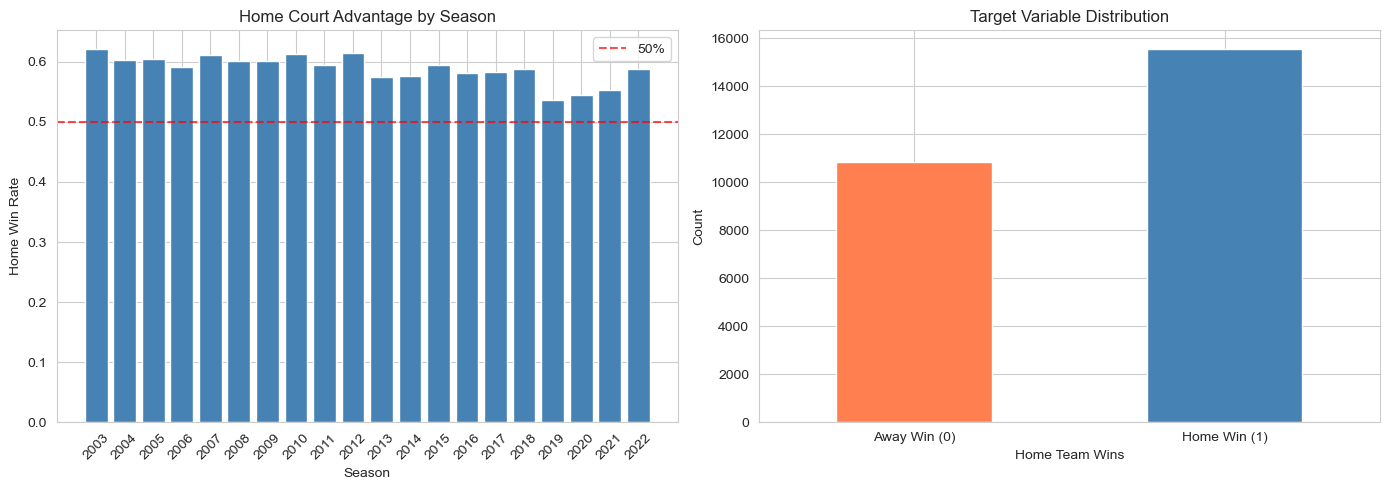

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_wr = model_df.groupby('SEASON')[target].mean()
axes[0].bar(season_wr.index.astype(str), season_wr.values, color='steelblue')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50%')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Home Win Rate')
axes[0].set_title('Home Court Advantage by Season')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

model_df[target].value_counts().sort_index().plot.bar(ax=axes[1], color=['coral', 'steelblue'])
axes[1].set_xlabel('Home Team Wins')
axes[1].set_ylabel('Count')
axes[1].set_title('Target Variable Distribution')
axes[1].set_xticklabels(['Away Win (0)', 'Home Win (1)'], rotation=0)

plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', bbox_inches='tight')
plt.show()

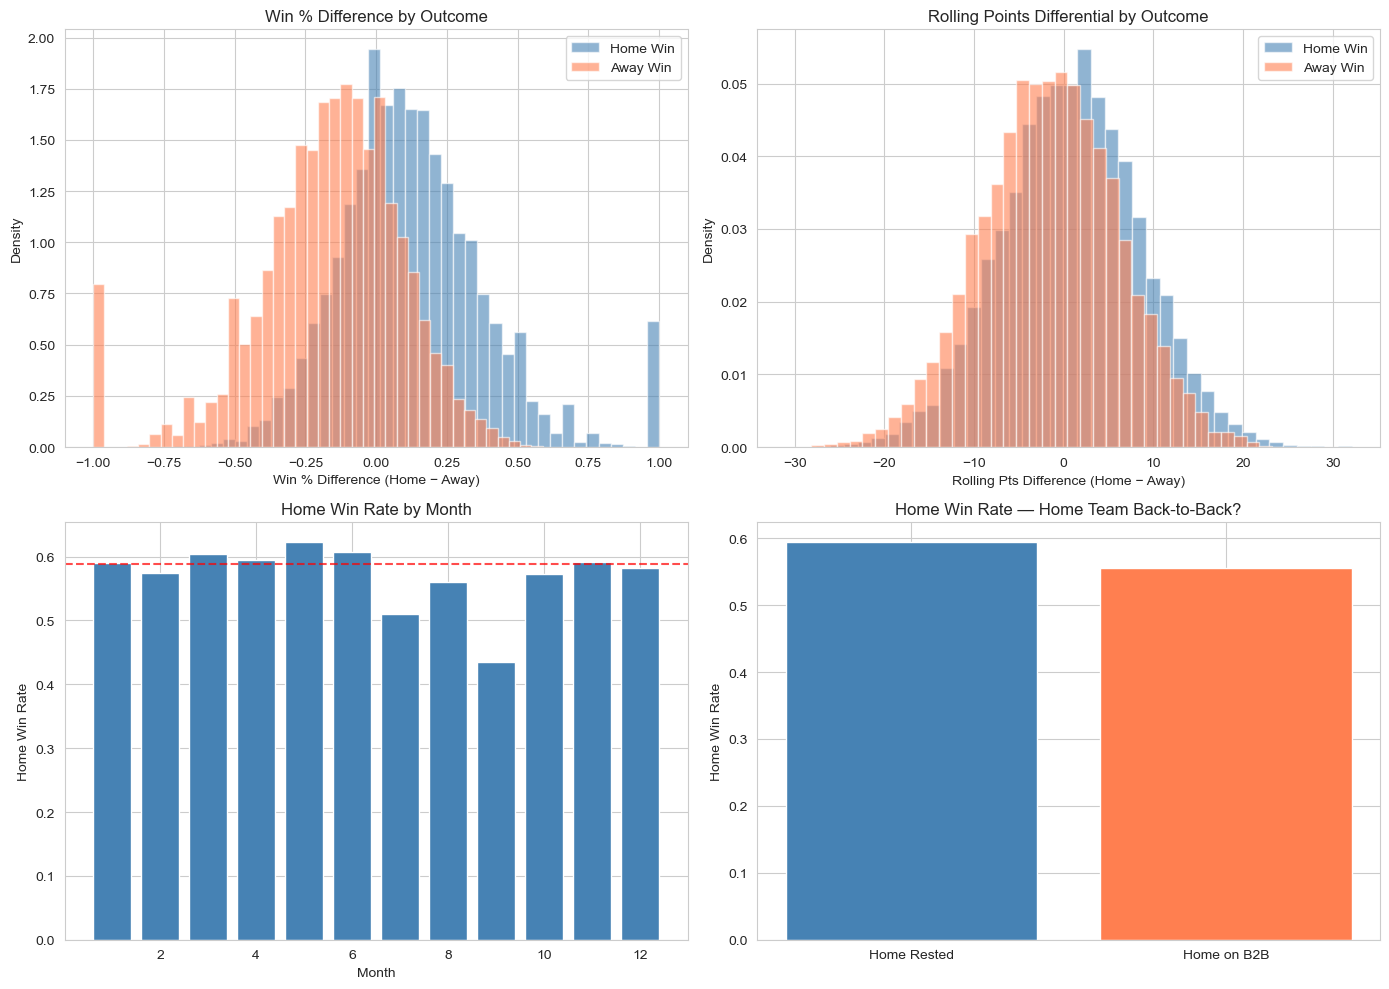

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for val, label, color in [(1, 'Home Win', 'steelblue'), (0, 'Away Win', 'coral')]:
    subset = model_df[model_df[target] == val]
    axes[0, 0].hist(subset['W_PCT_DIFF'], bins=40, alpha=0.6, label=label, color=color, density=True)
axes[0, 0].set_xlabel('Win % Difference (Home − Away)'); axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Win % Difference by Outcome'); axes[0, 0].legend()

for val, label, color in [(1, 'Home Win', 'steelblue'), (0, 'Away Win', 'coral')]:
    subset = model_df[model_df[target] == val]
    axes[0, 1].hist(subset['ROLL_PTS_DIFF'], bins=40, alpha=0.6, label=label, color=color, density=True)
axes[0, 1].set_xlabel('Rolling Pts Difference (Home − Away)'); axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Rolling Points Differential by Outcome'); axes[0, 1].legend()

# We plot against actual month from date, not the raw MONTH integer (which we dropped).
month_wr = model_df.assign(_month=model_df['GAME_DATE_EST'].dt.month).groupby('_month')[target].mean()
axes[1, 0].bar(month_wr.index, month_wr.values, color='steelblue')
axes[1, 0].axhline(y=model_df[target].mean(), color='red', linestyle='--', alpha=0.7)
axes[1, 0].set_xlabel('Month'); axes[1, 0].set_ylabel('Home Win Rate')
axes[1, 0].set_title('Home Win Rate by Month')

rest_wr = model_df.groupby('HOME_BACK_TO_BACK')[target].mean()
axes[1, 1].bar(['Home Rested', 'Home on B2B'], rest_wr.values, color=['steelblue', 'coral'])
axes[1, 1].set_ylabel('Home Win Rate')
axes[1, 1].set_title('Home Win Rate — Home Team Back-to-Back?')

plt.tight_layout()
plt.savefig('plots/02_feature_analysis.png', bbox_inches='tight')
plt.show()

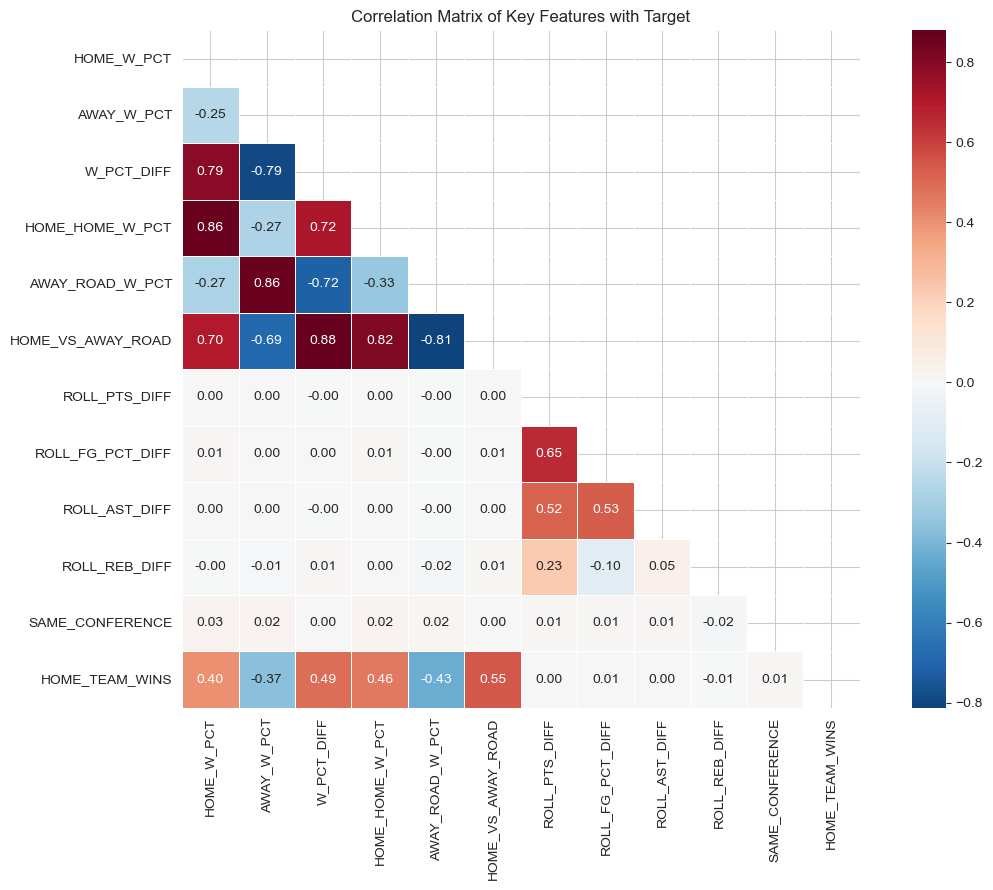

In [ ]:
corr_cols = ['HOME_W_PCT', 'AWAY_W_PCT', 'W_PCT_DIFF', 'HOME_HOME_W_PCT',
             'AWAY_ROAD_W_PCT', 'HOME_VS_AWAY_ROAD',
             'ROLL_PTS_DIFF', 'ROLL_FG_PCT_DIFF', 'ROLL_AST_DIFF', 'ROLL_REB_DIFF',
             'SAME_CONFERENCE', target]

fig, ax = plt.subplots(figsize=(12, 9))
corr = model_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix of Key Features with Target')
plt.tight_layout()
plt.savefig('plots/03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

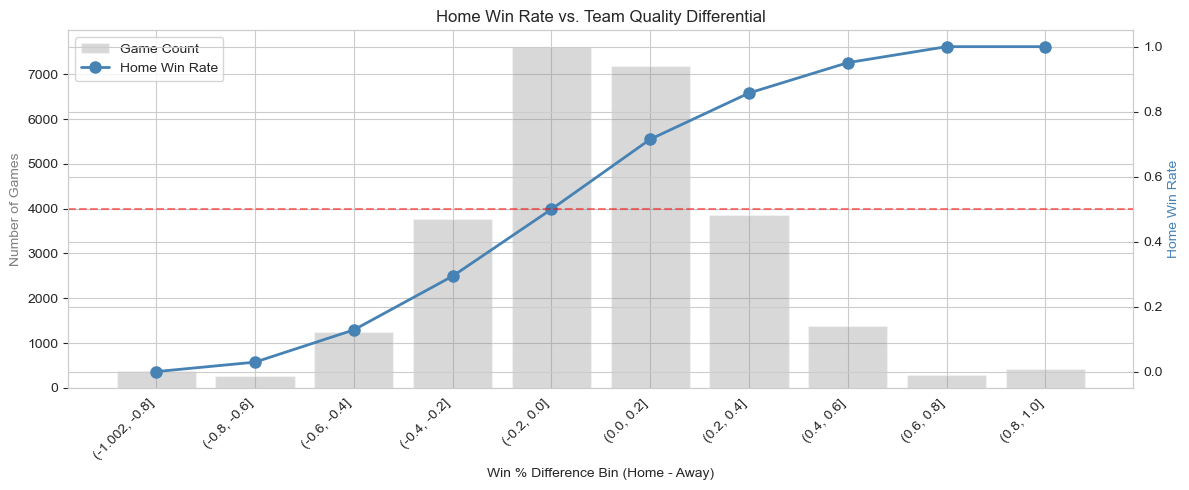

In [ ]:
model_df_plot = model_df.copy()
model_df_plot['W_PCT_DIFF_BIN'] = pd.cut(model_df_plot['W_PCT_DIFF'], bins=10)
bin_wr = model_df_plot.groupby('W_PCT_DIFF_BIN', observed=True)[target].agg(['mean', 'count'])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = range(len(bin_wr))
ax1.bar(x, bin_wr['count'], alpha=0.3, color='gray', label='Game Count')
ax2.plot(x, bin_wr['mean'], 'o-', color='steelblue', linewidth=2, markersize=8, label='Home Win Rate')
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

ax1.set_xlabel('Win % Difference Bin (Home - Away)')
ax1.set_ylabel('Number of Games', color='gray')
ax2.set_ylabel('Home Win Rate', color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels([str(b) for b in bin_wr.index], rotation=45, ha='right')
ax1.set_title('Home Win Rate vs. Team Quality Differential')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('plots/04_winrate_by_quality.png', bbox_inches='tight')
plt.show()

---
## 5. Train/Test Split and Baseline

We initially used the standard random train/test split. That's inappropriate because out rolling features are built from earlier games of the same season. For example, games from 2022 can end up in training, and games from 2003 in testing. We hold out the last two seasons (2021-2022)

In [28]:
train_mask = ~model_df['SEASON'].isin(TEST_SEASONS)
test_mask  =  model_df['SEASON'].isin(TEST_SEASONS)

train_df = model_df.loc[train_mask].sort_values('GAME_DATE_EST').reset_index(drop=True)
test_df  = model_df.loc[test_mask ].sort_values('GAME_DATE_EST').reset_index(drop=True)

X_train = train_df[feature_cols].values
y_train = train_df[target].values
X_test  = test_df[feature_cols].values
y_test  = test_df[target].values

print(f'Training set: {X_train.shape[0]:,} games | seasons {sorted(train_df["SEASON"].unique())}')
print(f'Test set:     {X_test.shape[0]:,} games | seasons {sorted(test_df["SEASON"].unique())}')
print(f'Features:     {X_train.shape[1]}')

baseline_acc = max(y_train.mean(), 1 - y_train.mean())
print(f'\nBaseline (always predict majority class): {baseline_acc:.4f}')

Training set: 24,461 games | seasons [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Test set:     1,931 games | seasons [np.int64(2021), np.int64(2022)]
Features:     37

Baseline (always predict majority class): 0.5910


---
## 6. Model Training and Cross-Validation

We train the following models as covered in class:
1. **Logistic Regression** (baseline ML model)
2. **Ridge Logistic Regression** (L2 regularized)
3. **Lasso Logistic Regression** (L1 regularized)
4. **Decision Tree**
5. **Random Forest**
6. **Gradient Boosting**
7. **XGBoost**

*Step 1:* We write two functions to streamline the process for training different models

In [29]:
results = {}
tscv = TimeSeriesSplit(n_splits=CV_SPLITS)


def manual_cv_search(estimator_factory, param_grid, X, y,
                     cv=tscv, scoring='accuracy', verbose=True):
    keys = list(param_grid.keys())
    sweep = []
    best_mean, best_params = -np.inf, None
    for values in product(*[param_grid[k] for k in keys]):
        params = dict(zip(keys, values))
        scores = cross_val_score(estimator_factory(**params), X, y,
                                 cv=cv, scoring=scoring, n_jobs=1)
        mean, std = scores.mean(), scores.std()
        sweep.append({**params, 'cv_mean': mean, 'cv_std': std})
        if verbose:
            print(f'    {params}  ->  CV {scoring}: {mean:.4f} ± {std:.4f}')
        if mean > best_mean:
            best_mean, best_params = mean, params
    return best_params, sweep


def evaluate_model(name, estimator, X_tr, X_te, y_tr, y_te, cv=tscv):
    estimator.fit(X_tr, y_tr)
    y_pred = estimator.predict(X_te)
    y_prob = estimator.predict_proba(X_te)[:, 1] if hasattr(estimator, 'predict_proba') else None

    acc   = accuracy_score(y_te, y_pred)
    f1    = f1_score(y_te, y_pred)
    auc   = roc_auc_score(y_te, y_prob)  if y_prob is not None else None
    brier = brier_score_loss(y_te, y_prob) if y_prob is not None else None
    ll    = log_loss(y_te, y_prob)         if y_prob is not None else None
    cv_scores = cross_val_score(estimator, X_tr, y_tr, cv=cv, scoring='accuracy', n_jobs=1)

    results[name] = {
        'model': estimator, 'test_acc': acc, 'test_auc': auc, 'test_f1': f1,
        'test_brier': brier, 'test_logloss': ll,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'y_pred': y_pred, 'y_prob': y_prob,
    }
    auc_str = f'{auc:.4f}' if auc is not None else 'N/A'
    print(f'  {name:26s} | CV-ts: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | '
          f'Test Acc: {acc:.4f} | AUC: {auc_str} | F1: {f1:.4f}')
    return estimator

### 6.1 Logistic Regression

In [30]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
evaluate_model('Logistic Regression', lr_pipe, X_train, X_test, y_train, y_test)

  Logistic Regression        | CV-ts: 0.7436 ± 0.0087 | Test Acc: 0.7405 | AUC: 0.8341 | F1: 0.7541


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

### 6.2 Ridge Logistic Regression (L2)

In [33]:
def make_ridge(C):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l2', C=C, max_iter=1000,
                                   class_weight='balanced', random_state=RANDOM_STATE))
    ])

print('Ridge Logistic — manual CV sweep over C:')
ridge_best, ridge_sweep = manual_cv_search(
    make_ridge, {'C': [0.01, 0.1, 1, 10]}, X_train, y_train
)
print(f'Best C (Ridge): {ridge_best["C"]}')
evaluate_model('Ridge Logistic (L2)', make_ridge(**ridge_best),
               X_train, X_test, y_train, y_test)

Ridge Logistic — manual CV sweep over C:
    {'C': 0.01}  ->  CV accuracy: 0.7443 ± 0.0086
    {'C': 0.1}  ->  CV accuracy: 0.7436 ± 0.0089
    {'C': 1}  ->  CV accuracy: 0.7436 ± 0.0087
    {'C': 10}  ->  CV accuracy: 0.7437 ± 0.0088
Best C (Ridge): 0.01
  Ridge Logistic (L2)        | CV-ts: 0.7443 ± 0.0086 | Test Acc: 0.7416 | AUC: 0.8339 | F1: 0.7550


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

### 6.3 Lasso Logistic Regression (L1)

In [34]:
def make_lasso(C):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(penalty='l1', solver='saga', C=C, max_iter=2000,
                                   class_weight='balanced', random_state=RANDOM_STATE))
    ])

print('Lasso Logistic — manual CV sweep over C:')
lasso_best, lasso_sweep = manual_cv_search(
    make_lasso, {'C': [0.01, 0.1, 1, 10]}, X_train, y_train
)
print(f'Best C (Lasso): {lasso_best["C"]}')
evaluate_model('Lasso Logistic (L1)', make_lasso(**lasso_best),
               X_train, X_test, y_train, y_test)

Lasso Logistic — manual CV sweep over C:
    {'C': 0.01}  ->  CV accuracy: 0.7418 ± 0.0104
    {'C': 0.1}  ->  CV accuracy: 0.7435 ± 0.0090
    {'C': 1}  ->  CV accuracy: 0.7436 ± 0.0087


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


    {'C': 10}  ->  CV accuracy: 0.7436 ± 0.0089
Best C (Lasso): 1
  Lasso Logistic (L1)        | CV-ts: 0.7436 ± 0.0087 | Test Acc: 0.7405 | AUC: 0.8340 | F1: 0.7541


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=2000,
                                    penalty='l1', random_state=42,
                                    solver='saga'))])

### 6.4 Decision Tree

In [35]:
def make_dt(max_depth, min_samples_leaf):
    return DecisionTreeClassifier(max_depth=max_depth,
                                  min_samples_leaf=min_samples_leaf,
                                  class_weight='balanced',
                                  random_state=RANDOM_STATE)

print('Decision Tree — manual CV sweep over (max_depth, min_samples_leaf):')
dt_best, dt_sweep = manual_cv_search(
    make_dt,
    {'max_depth': [3, 5, 10, 15], 'min_samples_leaf': [10, 20, 50]},
    X_train, y_train
)
print(f'Best params: {dt_best}')
evaluate_model('Decision Tree', make_dt(**dt_best),
               X_train, X_test, y_train, y_test)

Decision Tree — manual CV sweep over (max_depth, min_samples_leaf):
    {'max_depth': 3, 'min_samples_leaf': 10}  ->  CV accuracy: 0.7307 ± 0.0172
    {'max_depth': 3, 'min_samples_leaf': 20}  ->  CV accuracy: 0.7307 ± 0.0172
    {'max_depth': 3, 'min_samples_leaf': 50}  ->  CV accuracy: 0.7307 ± 0.0172
    {'max_depth': 5, 'min_samples_leaf': 10}  ->  CV accuracy: 0.7385 ± 0.0134
    {'max_depth': 5, 'min_samples_leaf': 20}  ->  CV accuracy: 0.7391 ± 0.0131
    {'max_depth': 5, 'min_samples_leaf': 50}  ->  CV accuracy: 0.7399 ± 0.0139
    {'max_depth': 10, 'min_samples_leaf': 10}  ->  CV accuracy: 0.7081 ± 0.0158
    {'max_depth': 10, 'min_samples_leaf': 20}  ->  CV accuracy: 0.7121 ± 0.0145
    {'max_depth': 10, 'min_samples_leaf': 50}  ->  CV accuracy: 0.7254 ± 0.0102
    {'max_depth': 15, 'min_samples_leaf': 10}  ->  CV accuracy: 0.6861 ± 0.0121
    {'max_depth': 15, 'min_samples_leaf': 20}  ->  CV accuracy: 0.7008 ± 0.0110
    {'max_depth': 15, 'min_samples_leaf': 50}  ->  CV accu

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=50, random_state=42)

### 6.5 Random Forest

In [36]:
def make_rf(n_estimators, max_depth, min_samples_leaf):
    return RandomForestClassifier(n_estimators=n_estimators,
                                  max_depth=max_depth,
                                  min_samples_leaf=min_samples_leaf,
                                  class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=1)

print('Random Forest — manual CV sweep over (n_estimators, max_depth, min_samples_leaf):')
rf_best, rf_sweep = manual_cv_search(
    make_rf,
    {'n_estimators': [100, 300], 'max_depth': [10, 15], 'min_samples_leaf': [10, 20]},
    X_train, y_train
)
print(f'Best params: {rf_best}')
evaluate_model('Random Forest', make_rf(**rf_best),
               X_train, X_test, y_train, y_test)

Random Forest — manual CV sweep over (n_estimators, max_depth, min_samples_leaf):
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 10}  ->  CV accuracy: 0.7401 ± 0.0093
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 20}  ->  CV accuracy: 0.7408 ± 0.0095
    {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 10}  ->  CV accuracy: 0.7438 ± 0.0081
    {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 20}  ->  CV accuracy: 0.7418 ± 0.0100
    {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 10}  ->  CV accuracy: 0.7410 ± 0.0095
    {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 20}  ->  CV accuracy: 0.7405 ± 0.0105
    {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 10}  ->  CV accuracy: 0.7434 ± 0.0077
    {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 20}  ->  CV accuracy: 0.7415 ± 0.0099
Best params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 10}
  Random Forest              | CV-

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=10, n_jobs=1, random_state=42)

### 6.6 Gradient Boosting

In [37]:
def make_gb(n_estimators, max_depth, learning_rate):
    return GradientBoostingClassifier(n_estimators=n_estimators,
                                      max_depth=max_depth,
                                      learning_rate=learning_rate,
                                      random_state=RANDOM_STATE)

print('Gradient Boosting — manual CV sweep over (n_estimators, max_depth, learning_rate):')
gb_best, gb_sweep = manual_cv_search(
    make_gb,
    {'n_estimators': [100, 300], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    X_train, y_train
)
print(f'Best params: {gb_best}')
evaluate_model('Gradient Boosting', make_gb(**gb_best),
               X_train, X_test, y_train, y_test)

Gradient Boosting — manual CV sweep over (n_estimators, max_depth, learning_rate):
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}  ->  CV accuracy: 0.7504 ± 0.0070
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}  ->  CV accuracy: 0.7504 ± 0.0083
    {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}  ->  CV accuracy: 0.7474 ± 0.0068
    {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}  ->  CV accuracy: 0.7438 ± 0.0075
    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05}  ->  CV accuracy: 0.7489 ± 0.0082
    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1}  ->  CV accuracy: 0.7427 ± 0.0096
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}  ->  CV accuracy: 0.7416 ± 0.0087
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}  ->  CV accuracy: 0.7378 ± 0.0101
Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
  Gradient Boosting          | CV-ts: 0.7504 ± 0.0070 |

GradientBoostingClassifier(learning_rate=0.05, random_state=42)

### 6.7 XGBoost

We use scale_pos_weight for the class imbalance (positive = home win)

In [38]:
spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

def make_xgb(n_estimators, max_depth, learning_rate):
    return XGBClassifier(n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         random_state=RANDOM_STATE,
                         eval_metric='logloss',
                         verbosity=0,
                         scale_pos_weight=spw,
                         n_jobs=1)

print('XGBoost — manual CV sweep over (n_estimators, max_depth, learning_rate):')
xgb_best, xgb_sweep = manual_cv_search(
    make_xgb,
    {'n_estimators': [100, 300], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    X_train, y_train
)
print(f'Best params: {xgb_best}')
evaluate_model('XGBoost', make_xgb(**xgb_best),
               X_train, X_test, y_train, y_test)

XGBoost — manual CV sweep over (n_estimators, max_depth, learning_rate):
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}  ->  CV accuracy: 0.7396 ± 0.0127
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}  ->  CV accuracy: 0.7407 ± 0.0107
    {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}  ->  CV accuracy: 0.7425 ± 0.0088
    {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}  ->  CV accuracy: 0.7395 ± 0.0095
    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05}  ->  CV accuracy: 0.7403 ± 0.0104
    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1}  ->  CV accuracy: 0.7380 ± 0.0101
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}  ->  CV accuracy: 0.7359 ± 0.0101
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}  ->  CV accuracy: 0.7328 ± 0.0093
Best params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
  XGBoost                    | CV-ts: 0.7425 ± 0.0088 | Test Acc:

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=1,
              num_parallel_tree=None, ...)

---
## 7. Model Comparison

We sort the models by AUC rather than accuracy because AUC is robust to the class balance and it does not depend on an assigned threshold.

In [39]:
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'CV Accuracy': [r['cv_mean'] for r in results.values()],
    'CV Std': [r['cv_std'] for r in results.values()],
    'Test Accuracy': [r['test_acc'] for r in results.values()],
    'Test AUC':[r['test_auc'] for r in results.values()],
    'Test F1': [r['test_f1'] for r in results.values()],
    'Test Brier':[r['test_brier'] for r in results.values()],
    'Test LogLoss':[r['test_logloss'] for r in results.values()],
}).sort_values('Test AUC', ascending=False).reset_index(drop=True)

print('MODEL COMPARISON')
print('=' * 100)
display(comparison)
print(f'\nBaseline accuracy (majority class): {baseline_acc:.4f}')

MODEL COMPARISON


,Model,CV Accuracy,CV Std,Test Accuracy,Test AUC,Test F1,Test Brier,Test LogLoss
0,Logistic Regression,0.743572,0.008661,0.740549,0.834068,0.754050,0.169853,0.501768
1,Lasso Logistic (L1),0.743621,0.008660,0.740549,0.834025,0.754050,0.169878,0.501828
2,Ridge Logistic (L2),0.744259,0.008574,0.741585,0.833906,0.755032,0.169760,0.501771
3,Gradient Boosting,0.750393,0.006977,0.748835,0.833402,0.778438,0.164529,0.488343
4,XGBoost,0.742542,0.008803,0.735888,0.832816,0.747774,0.170498,0.498311
5,Decision Tree,0.739941,0.013867,0.716727,0.829497,0.713463,0.172932,0.509695
6,Random Forest,0.743817,0.008068,0.738995,0.829143,0.756991,0.169709,0.502573



Baseline accuracy (majority class): 0.5910


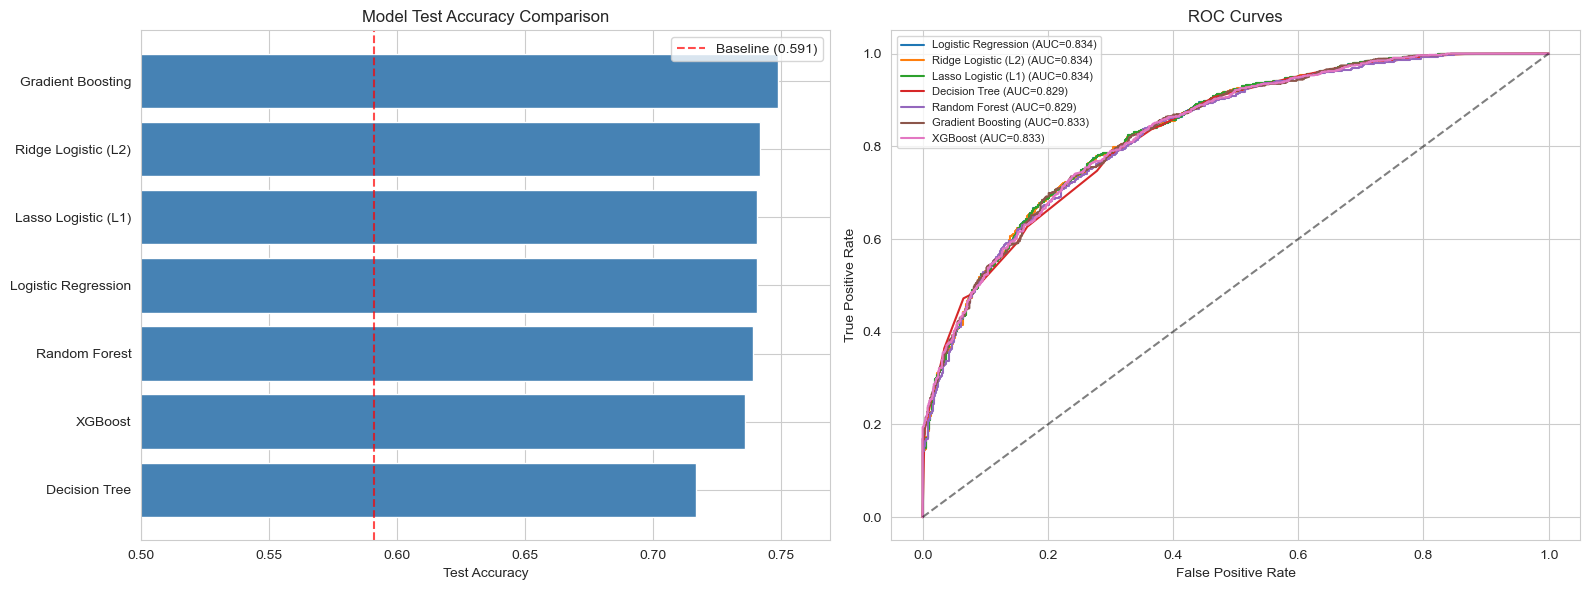

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_sorted = comparison.sort_values('Test Accuracy')
colors = ['steelblue' if acc > baseline_acc else 'coral' for acc in models_sorted['Test Accuracy']]
axes[0].barh(models_sorted['Model'], models_sorted['Test Accuracy'], color=colors)
axes[0].axvline(x=baseline_acc, color='red', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_acc:.3f})')
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Model Test Accuracy Comparison')
axes[0].legend()
axes[0].set_xlim(0.5, max(models_sorted['Test Accuracy']) + 0.02)

for name, r in results.items():
    if r['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
        axes[1].plot(fpr, tpr, label=f"{name} (AUC={r['test_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/05_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 8. Best Model Analysis

In [47]:
best_name = comparison.iloc[3]['Model']
best = results[best_name]
print(f'Best model: {best_name}')
print(f'Test Accuracy: {best["test_acc"]:.4f}')
print(f'Test AUC: {best["test_auc"]:.4f}')
print(f'Test F1: {best["test_f1"]:.4f}')
print(f'Test Brier: {best["test_brier"]:.4f}')
print(f'Test Log Loss: {best["test_logloss"]:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, best['y_pred'], target_names=['Away Win', 'Home Win']))

Best model: Gradient Boosting
Test Accuracy: 0.7488
Test AUC: 0.8334
Test F1: 0.7784
Test Brier: 0.1645
Test Log Loss: 0.4883

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.72      0.70      0.71       844
    Home Win       0.77      0.78      0.78      1087

    accuracy                           0.75      1931
   macro avg       0.74      0.74      0.74      1931
weighted avg       0.75      0.75      0.75      1931



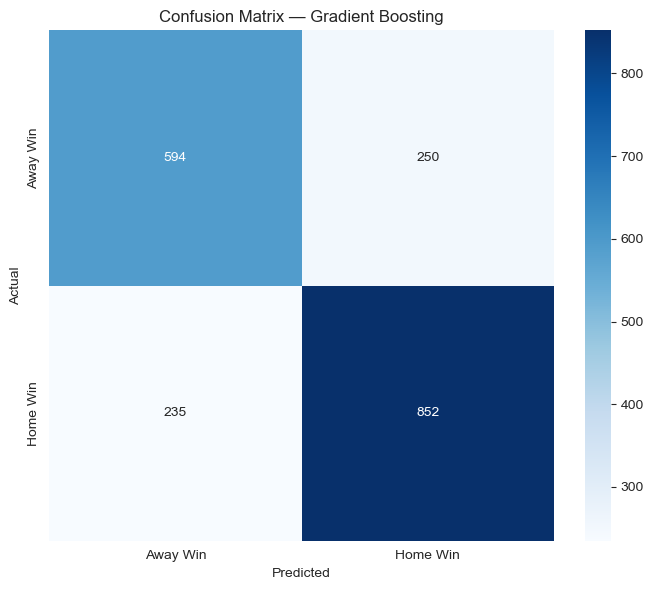

In [48]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.savefig('plots/06_confusion_matrix.png', bbox_inches='tight')
plt.show()

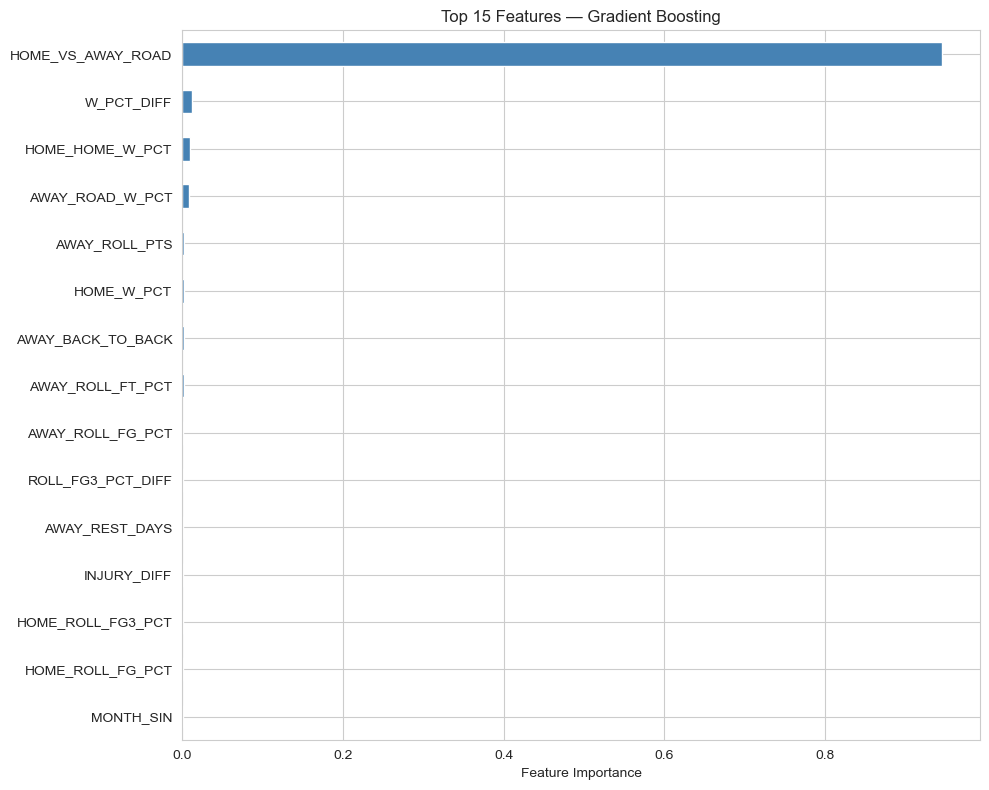

In [49]:
best_model = best['model']

final_est = best_model.named_steps['clf'] if hasattr(best_model, 'named_steps') else best_model

if hasattr(final_est, 'feature_importances_'):
    importances = final_est.feature_importances_
    imp_label = 'Feature Importance'
elif hasattr(final_est, 'coef_'):
    importances = np.abs(final_est.coef_[0])
    imp_label = 'Absolute Coefficient'
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    feat_imp.tail(15).plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel(imp_label); ax.set_title(f'Top 15 Features — {best_name}')
    plt.tight_layout()
    plt.savefig('plots/07_feature_importance.png', bbox_inches='tight')
    plt.show()

---
## 9. Effect of Parameter Tuning

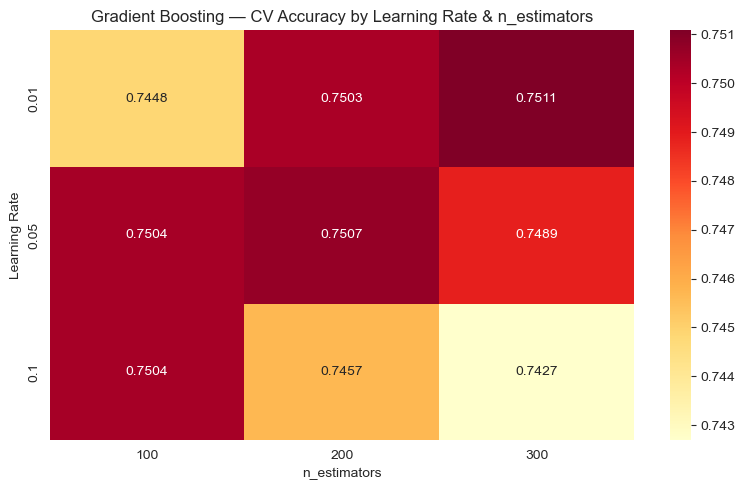

In [45]:
lr_values = [0.01, 0.05, 0.1]
n_values = [100, 200, 300]
gb_heatmap = np.zeros((len(lr_values), len(n_values)))

for i, lr_val in enumerate(lr_values):
    for j, n in enumerate(n_values):
        gb = GradientBoostingClassifier(n_estimators=n, learning_rate=lr_val,
                                        max_depth=3, random_state=RANDOM_STATE)
        gb_heatmap[i, j] = cross_val_score(gb, X_train, y_train, cv=tscv,
                                           scoring='accuracy', n_jobs=1).mean()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(gb_heatmap, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=n_values, yticklabels=lr_values, ax=ax)
ax.set_xlabel('n_estimators'); ax.set_ylabel('Learning Rate')
ax.set_title('Gradient Boosting — CV Accuracy by Learning Rate & n_estimators')
plt.tight_layout()
plt.savefig('plots/09_gb_tuning_heatmap.png', bbox_inches='tight')
plt.show()

In [46]:
print('FINAL MODEL COMPARISON')
print('=' * 80)
display(comparison)
print(f'\nBaseline (majority class): {baseline_acc:.4f}')
print(f'Best model: {best_name} — Test Acc: {best["test_acc"]:.4f}, AUC: {best["test_auc"]:.4f}')

FINAL MODEL COMPARISON


,Model,CV Accuracy,CV Std,Test Accuracy,Test AUC,Test F1,Test Brier,Test LogLoss
0,Logistic Regression,0.743572,0.008661,0.740549,0.834068,0.754050,0.169853,0.501768
1,Lasso Logistic (L1),0.743621,0.008660,0.740549,0.834025,0.754050,0.169878,0.501828
2,Ridge Logistic (L2),0.744259,0.008574,0.741585,0.833906,0.755032,0.169760,0.501771
3,Gradient Boosting,0.750393,0.006977,0.748835,0.833402,0.778438,0.164529,0.488343
4,XGBoost,0.742542,0.008803,0.735888,0.832816,0.747774,0.170498,0.498311
5,Decision Tree,0.739941,0.013867,0.716727,0.829497,0.713463,0.172932,0.509695
6,Random Forest,0.743817,0.008068,0.738995,0.829143,0.756991,0.169709,0.502573



Baseline (majority class): 0.5910
Best model: Logistic Regression — Test Acc: 0.7405, AUC: 0.8341
